<a href="https://colab.research.google.com/github/Ronglawan/AI-in-Financial-Reporting-and-Fraud-Detection/blob/main/Final_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Exploration

## Import Libraries

In [25]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

# Graph Settings
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Dataset

In [26]:
df = pd.read_csv("/content/drive/MyDrive/AI in Financial Reporting and Fraud Detection/Synthetic_Financial_datasets_log.csv")

print(df.shape)

df.head()

(6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


##  Dataset Information

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


## Statistical Summary

In [29]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00
isFlaggedFraud,6362620.0,2.514687e-06,1.585775e-03,0.0,0.00,0.000,0.000000e+00,1.000000e+00


## Missing Values

In [30]:
missing = pd.DataFrame({
    "Missing Value": df.isnull().sum(),
    "Percentage (%)": round(df.isnull().mean()*100,2)
})

missing

,Missing Value,Percentage (%)
step,0,0.0
type,0,0.0
amount,0,0.0
nameOrig,0,0.0
oldbalanceOrg,0,0.0
newbalanceOrig,0,0.0
nameDest,0,0.0
oldbalanceDest,0,0.0
newbalanceDest,0,0.0
isFraud,0,0.0


## Duplicate Records

In [31]:
duplicate = df.duplicated().sum()

print("Duplicate Records :", duplicate)

Duplicate Records : 0


## Dataset Summary Table

In [32]:
summary = pd.DataFrame({

    "Column":df.columns,

    "Data Type":df.dtypes.values,

    "Missing":df.isnull().sum().values,

    "Unique":df.nunique().values

})

summary

,Column,Data Type,Missing,Unique
0,step,int64,0,743
1,type,object,0,5
2,amount,float64,0,5316900
3,nameOrig,object,0,6353307
4,oldbalanceOrg,float64,0,1845844
5,newbalanceOrig,float64,0,2682586
6,nameDest,object,0,2722362
7,oldbalanceDest,float64,0,3614697
8,newbalanceDest,float64,0,3555499
9,isFraud,int64,0,2


## Fraud Distribution

,Count,Percentage
isFraud,,
0,6354407,99.87
1,8213,0.13


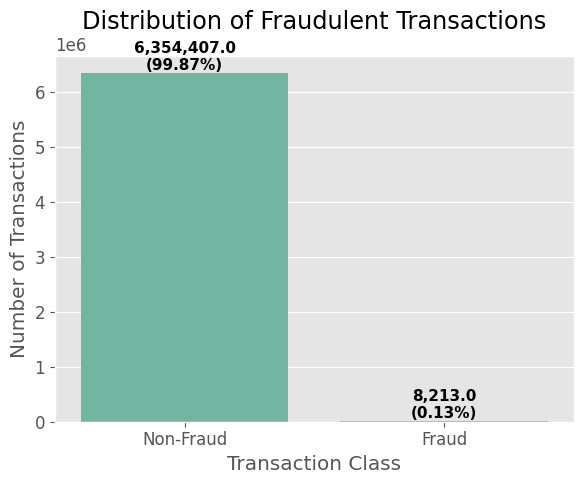

In [34]:
fraud = df["isFraud"].value_counts()

fraud_percent = round(df["isFraud"].value_counts(normalize=True)*100,2)

display(pd.DataFrame({
    "Count":fraud,
    "Percentage":fraud_percent
}))

plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="isFraud",
    palette="Set2"
)

ax.set_xticklabels(["Non-Fraud","Fraud"])

plt.title("Distribution of Fraudulent Transactions")

plt.xlabel("Transaction Class")

plt.ylabel("Number of Transactions")

total = len(df)

for p in ax.patches:

    height = p.get_height()

    ax.annotate(

        f'{height:,}\n({height/total*100:.2f}%)',

        (p.get_x()+p.get_width()/2,height),

        ha='center',

        va='bottom',

        fontsize=11,

        fontweight='bold'

    )

plt.tight_layout()

plt.show()

## Transaction Type

,count
type,
CASH_OUT,2237500
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,532909
DEBIT,41432


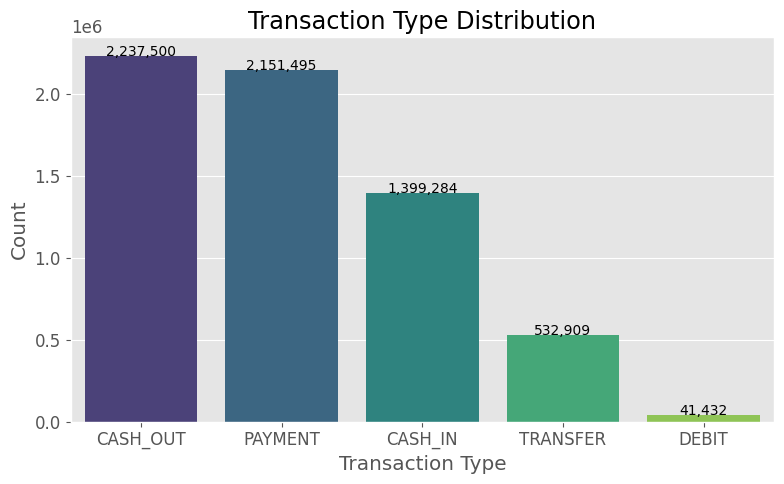

In [36]:
transaction = df["type"].value_counts()

display(transaction)

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="type",
    order=df["type"].value_counts().index,
    palette="viridis"
)

plt.title("Transaction Type Distribution")

plt.xlabel("Transaction Type")

plt.ylabel("Count")

for p in ax.patches:

    ax.annotate(

        f'{int(p.get_height()):,}',

        (p.get_x()+p.get_width()/2,p.get_height()),

        ha='center',

        fontsize=10

    )

plt.tight_layout()

plt.show()

## Fraud by Transaction Type

,Non-Fraud,Fraud
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


<Figure size 800x500 with 0 Axes>

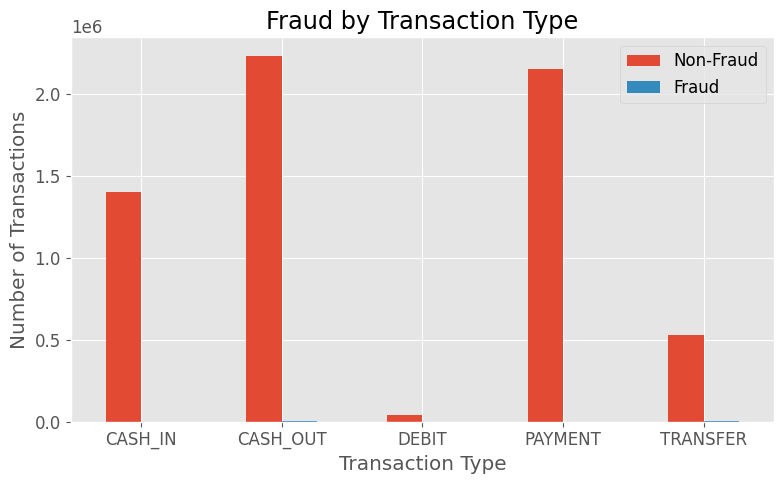

In [38]:
fraud_type = pd.crosstab(
    df["type"],
    df["isFraud"]
)

fraud_type.columns=["Non-Fraud","Fraud"]

display(fraud_type)

plt.figure(figsize=(8,5))

fraud_type.plot(
    kind="bar",
    stacked=False,
    figsize=(8,5)
)

plt.title("Fraud by Transaction Type")

plt.xlabel("Transaction Type")

plt.ylabel("Number of Transactions")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

# Amount Distribution

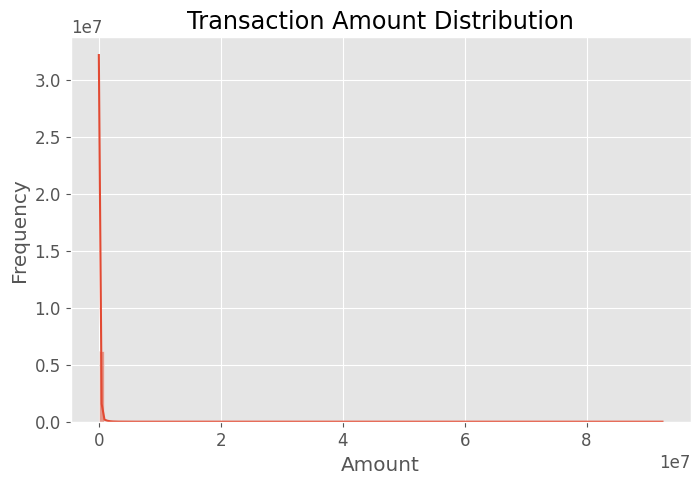

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["amount"],
    bins=100,
    kde=True
)

plt.title("Transaction Amount Distribution")

plt.xlabel("Amount")

plt.ylabel("Frequency")

plt.show()

## Amount Boxplot

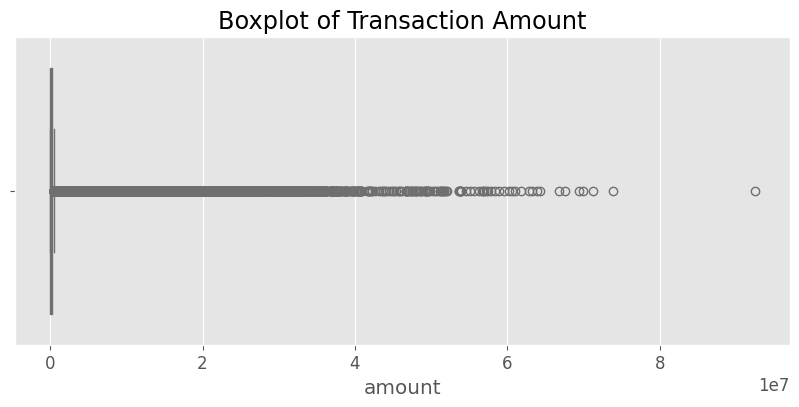

In [42]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df["amount"],
    color="skyblue"
)

plt.title("Boxplot of Transaction Amount")

plt.show()

## Correlation Heatmap

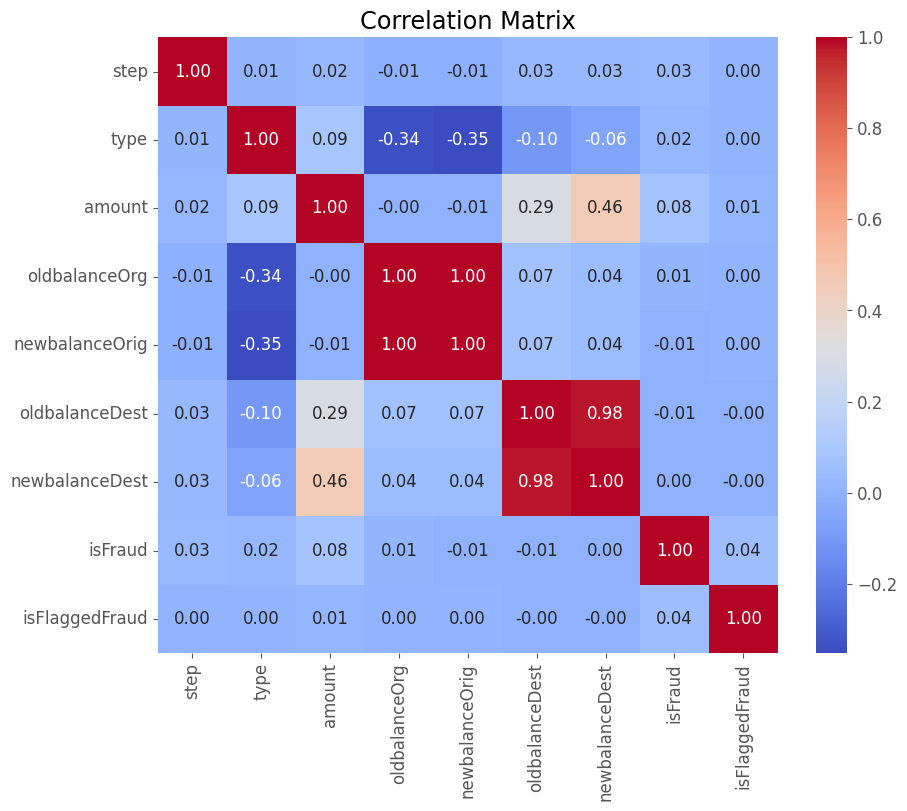

In [43]:
temp = df.copy()

encoder = LabelEncoder()

temp["type"] = encoder.fit_transform(temp["type"])

plt.figure(figsize=(10,8))

sns.heatmap(
    temp.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

# Data Preprocessing

## Remove Unnecessary Columns

In [44]:
drop_columns = [
    "nameOrig",
    "nameDest",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

df = df.drop(columns=drop_columns)

print("Dataset Shape :", df.shape)
df.head()

Dataset Shape : (6362620, 5)


,step,type,amount,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,0,0
1,1,PAYMENT,1864.28,0,0
2,1,TRANSFER,181.00,1,0
3,1,CASH_OUT,181.00,1,0
4,1,PAYMENT,11668.14,0,0


# Encode Transaction Type

In [45]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["type"] = encoder.fit_transform(df["type"])

mapping = pd.DataFrame({
    "Transaction Type": encoder.classes_,
    "Encoded": encoder.transform(encoder.classes_)
})

mapping

,Transaction Type,Encoded
0,CASH_IN,0
1,CASH_OUT,1
2,DEBIT,2
3,PAYMENT,3
4,TRANSFER,4


# Feature Engineering

In [47]:
df["hour"] = df["step"] % 24

df["day"] = (df["step"] // 24) + 1

df[["step","hour","day"]].head()

,step,hour,day
0,1,1,1
1,1,1,1
2,1,1,1
3,1,1,1
4,1,1,1


## Remove Step

In [48]:
df = df.drop(columns=["step"])

print(df.columns)

Index(['type', 'amount', 'isFraud', 'isFlaggedFraud', 'hour', 'day'], dtype='object')


## Dataset

In [49]:
print(df.info())

df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   type            int64  
 1   amount          float64
 2   isFraud         int64  
 3   isFlaggedFraud  int64  
 4   hour            int64  
 5   day             int64  
dtypes: float64(1), int64(5)
memory usage: 291.3 MB
None


,count,mean,std,min,25%,50%,75%,max
type,6362620.0,1.714150,1.350117,0.0,1.00,1.00,3.0000,4.00
amount,6362620.0,179861.903549,603858.231463,0.0,13389.57,74871.94,208721.4775,92445516.64
isFraud,6362620.0,0.001291,0.035905,0.0,0.00,0.00,0.0000,1.00
isFlaggedFraud,6362620.0,0.000003,0.001586,0.0,0.00,0.00,0.0000,1.00
hour,6362620.0,15.321454,4.321799,0.0,12.00,16.00,19.0000,23.00
day,6362620.0,10.503158,5.922111,1.0,7.00,10.00,14.0000,31.00


## Correlation Matrix

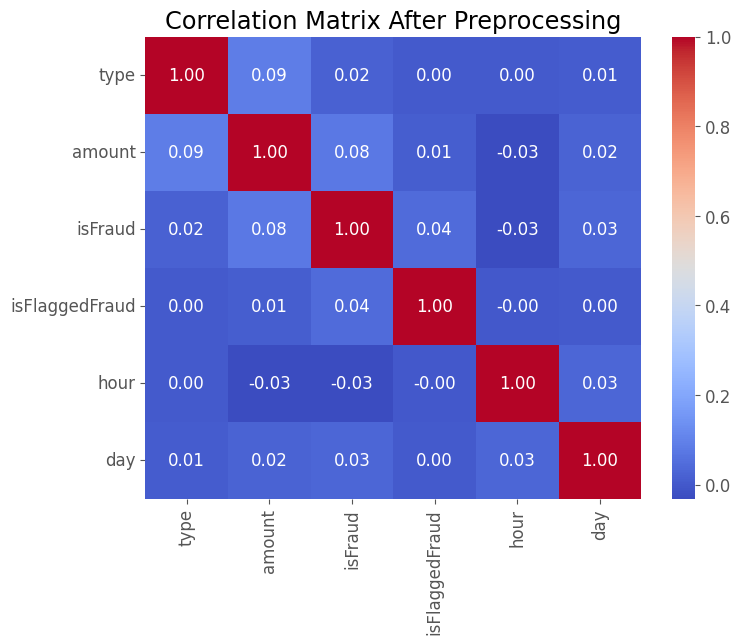

In [50]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix After Preprocessing")

plt.show()

## Feature Selection

In [51]:
X = df.drop(columns=["isFraud"])

y = df["isFraud"]

print("Features")

display(X.head())

print("\nTarget")

display(y.head())

Features


,type,amount,isFlaggedFraud,hour,day
0,3,9839.64,0,1,1
1,3,1864.28,0,1,1
2,4,181.00,0,1,1
3,1,181.00,0,1,1
4,3,11668.14,0,1,1



Target


,isFraud
0,0
1,0
2,1
3,1
4,0


## Feature List

In [52]:
feature_table = pd.DataFrame({

    "Feature":X.columns,

    "Data Type":X.dtypes.values

})

feature_table

,Feature,Data Type
0,type,int64
1,amount,float64
2,isFlaggedFraud,int64
3,hour,int64
4,day,int64


## Train-Test Split

In [53]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training :",X_train.shape)

print("Testing :",X_test.shape)

Training : (5090096, 5)
Testing : (1272524, 5)


## Class Distribution

,Count,Percentage (%)
isFraud,,
0,5083526,99.87
1,6570,0.13


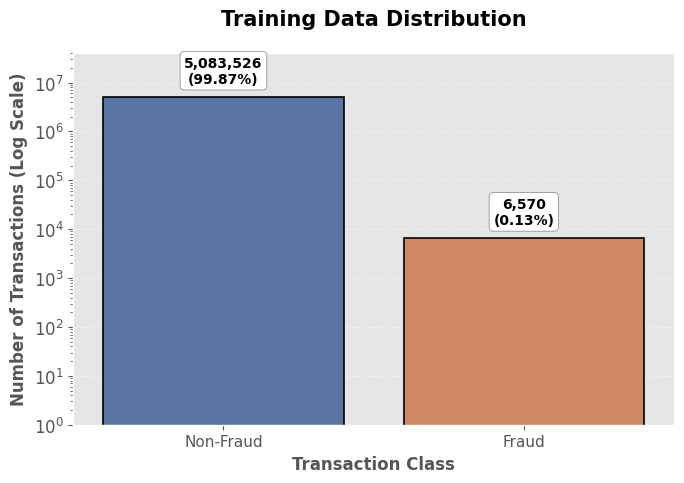

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import LogLocator, LogFormatterMathtext

# --------------------------
# Summary Table
# --------------------------

train_class = pd.DataFrame({
    "Count": y_train.value_counts(),
    "Percentage (%)": round(y_train.value_counts(normalize=True) * 100, 2)
})

display(train_class)

# --------------------------
# Plot
# --------------------------

plt.figure(figsize=(7,5))

ax = sns.countplot(
    x=y_train,
    palette=["#4C72B0", "#DD8452"],
    edgecolor="black",
    linewidth=1.2
)

# X-axis labels
ax.set_xticklabels(["Non-Fraud", "Fraud"], fontsize=11)

# Log Scale
ax.set_yscale("log")

# แสดงเป็น 10^0, 10^1, ...
ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_formatter(LogFormatterMathtext())

# ชื่อกราฟ
plt.title(
    "Training Data Distribution",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Transaction Class",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Transactions (Log Scale)",
    fontsize=12,
    fontweight="bold"
)

# Grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

# เว้นพื้นที่ด้านบน
ax.set_ylim(
    bottom=1,
    top=max(y_train.value_counts()) * 8
)

# --------------------------
# Annotation
# --------------------------

total = len(y_train)

for p in ax.patches:

    height = p.get_height()

    ax.annotate(
        f"{int(height):,}\n({height/total*100:.2f}%)",
        xy=(p.get_x()+p.get_width()/2, height),
        xytext=(0,8),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="gray",
            boxstyle="round,pad=0.3"
        )
    )

plt.tight_layout()

plt.show()

## Feature Scaling

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Complete")

Scaling Complete


# Machine Learning Model Training

## Import Libraries

In [62]:
!pip -q install xgboost lightgbm

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import time

## Define Models

In [64]:
models = {

    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        class_weight="balanced",
        random_state=42
    )

}

## Train Function

In [67]:
results = []

trained_models = {}

for name, model in models.items():

    print("="*60)
    print(f"Training : {name}")

    start = time.time()

    # Logistic Regression ใช้ข้อมูลที่ Scale แล้ว
    if name == "Logistic Regression":

        model.fit(X_train_scaled, y_train)

        pred = model.predict(X_test_scaled)

        prob = model.predict_proba(X_test_scaled)[:,1]

    else:

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        prob = model.predict_proba(X_test)[:,1]

    end = time.time()

    trained_models[name] = model

    results.append({

        "Model":name,

        "Accuracy":accuracy_score(y_test,pred),

        "Precision":precision_score(y_test,pred),

        "Recall":recall_score(y_test,pred),

        "F1-Score":f1_score(y_test,pred),

        "ROC-AUC":roc_auc_score(y_test,prob),

        "Training Time (s)":round(end-start,2)

    })

    print(f"Finished in {end-start:.2f} seconds")

Training : Logistic Regression
Finished in 10.92 seconds
Training : Decision Tree
Finished in 91.72 seconds
Training : Random Forest
Finished in 2667.92 seconds
Training : XGBoost
Finished in 96.34 seconds
Training : LightGBM
[LightGBM] [Info] Number of positive: 6570, number of negative: 5083526
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.072401 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 318
[LightGBM] [Info] Number of data points in the train set: 5090096, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Finished in 108.74 seconds


## Model Comparison

In [68]:
result_df = pd.DataFrame(results)

result_df = result_df.sort_values(
    by="F1-Score",
    ascending=False
)

result_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s)
3,XGBoost,0.999219,0.925295,0.429702,0.586866,0.972191,96.34
2,Random Forest,0.999117,0.769470,0.451004,0.568688,0.880497,2667.92
1,Decision Tree,0.998721,0.505006,0.491175,0.497994,0.745306,91.72
4,LightGBM,0.938534,0.018318,0.886184,0.035893,0.974690,108.74
0,Logistic Regression,0.874446,0.007469,0.729763,0.014787,0.854281,10.92


## Highlight Best Model

In [76]:
result_df.style.highlight_max(
    subset=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    color="green"
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s)
3,XGBoost,0.999219,0.925295,0.429702,0.586866,0.972191,96.340000
2,Random Forest,0.999117,0.769470,0.451004,0.568688,0.880497,2667.920000
1,Decision Tree,0.998721,0.505006,0.491175,0.497994,0.745306,91.720000
4,LightGBM,0.938534,0.018318,0.886184,0.035893,0.974690,108.740000
0,Logistic Regression,0.874446,0.007469,0.729763,0.014787,0.854281,10.920000


## Save Result

In [70]:
result_df.to_csv("Model_Comparison.csv",index=False)

print("Result Saved")

Result Saved


# Model Evaluation

## Classification Report and Confusion Matrix

[DETAILED REPORT] Logistic Regression
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.87      0.93   1270881
       Fraud       0.01      0.73      0.01      1643

    accuracy                           0.87   1272524
   macro avg       0.50      0.80      0.47   1272524
weighted avg       1.00      0.87      0.93   1272524



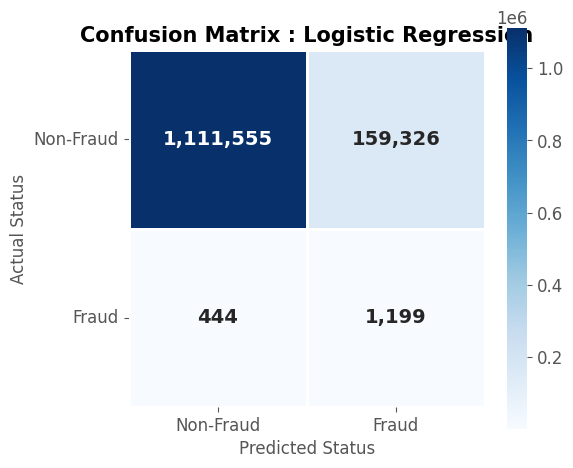

[DETAILED REPORT] Decision Tree
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00   1270881
       Fraud       0.51      0.49      0.50      1643

    accuracy                           1.00   1272524
   macro avg       0.75      0.75      0.75   1272524
weighted avg       1.00      1.00      1.00   1272524



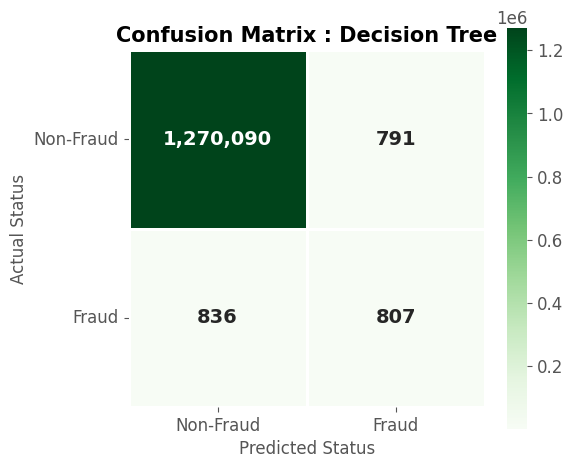

[DETAILED REPORT] Random Forest
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00   1270881
       Fraud       0.77      0.45      0.57      1643

    accuracy                           1.00   1272524
   macro avg       0.88      0.73      0.78   1272524
weighted avg       1.00      1.00      1.00   1272524



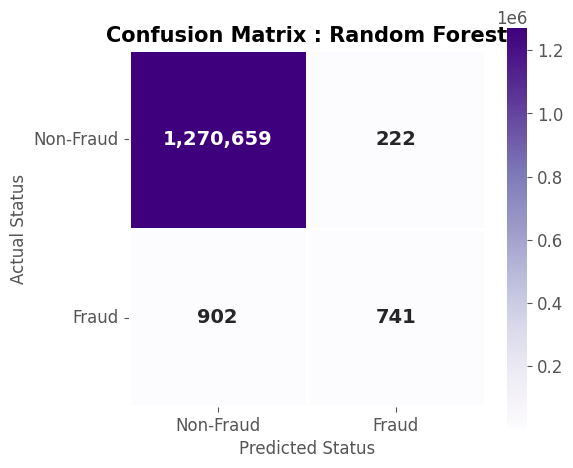

[DETAILED REPORT] XGBoost
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00   1270881
       Fraud       0.93      0.43      0.59      1643

    accuracy                           1.00   1272524
   macro avg       0.96      0.71      0.79   1272524
weighted avg       1.00      1.00      1.00   1272524



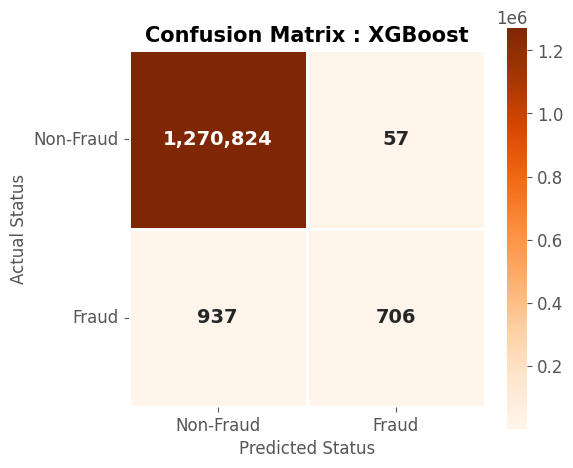

[DETAILED REPORT] LightGBM
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.94      0.97   1270881
       Fraud       0.02      0.89      0.04      1643

    accuracy                           0.94   1272524
   macro avg       0.51      0.91      0.50   1272524
weighted avg       1.00      0.94      0.97   1272524



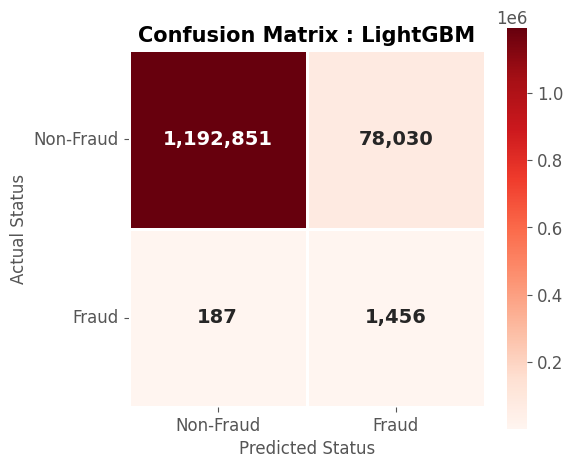

In [75]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

model_colors = {
    "Logistic Regression": "Blues",
    "Decision Tree": "Greens",
    "Random Forest": "Purples",
    "XGBoost": "Oranges",
    "LightGBM": "Reds"
}

for name, model in trained_models.items():

    # เลือกข้อมูล
    if name == "Logistic Regression":
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    # Classification Report
    print("="*80)
    print(f"[DETAILED REPORT] {name}")
    print("="*80)

    print(classification_report(
        y_test,
        y_pred,
        target_names=["Non-Fraud", "Fraud"]
    ))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt=",",
        cmap=model_colors[name],     # <-- เปลี่ยนสีตามโมเดล
        linewidths=1,
        linecolor="white",
        square=True,
        cbar=True,
        annot_kws={
            "fontsize":14,
            "fontweight":"bold"
        }
    )

    plt.title(
        f"Confusion Matrix : {name}",
        fontsize=15,
        fontweight="bold"
    )

    plt.xlabel("Predicted Status", fontsize=12)
    plt.ylabel("Actual Status", fontsize=12)

    plt.xticks(
        [0.5,1.5],
        ["Non-Fraud","Fraud"]
    )

    plt.yticks(
        [0.5,1.5],
        ["Non-Fraud","Fraud"],
        rotation=0
    )

    plt.tight_layout()
    plt.show()

## ROC Curve

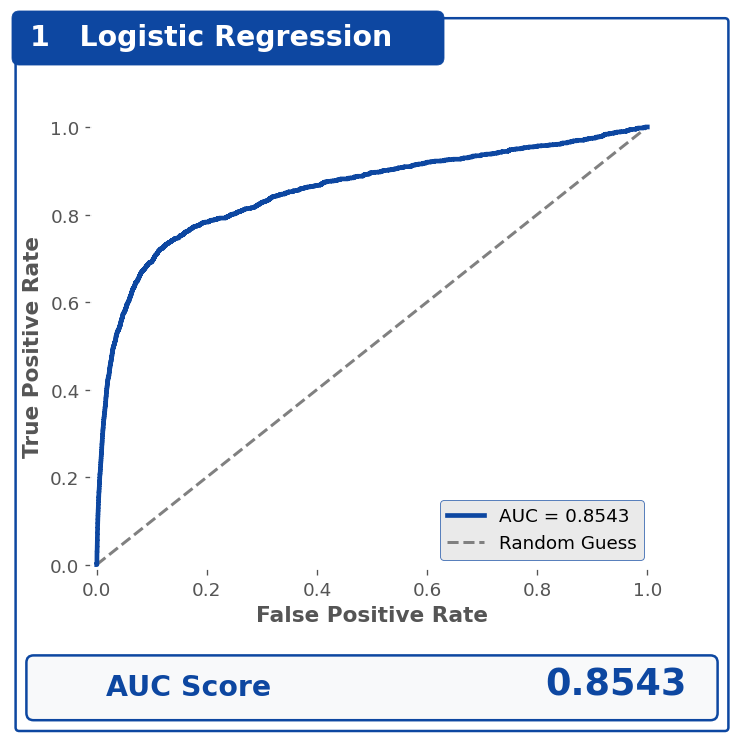

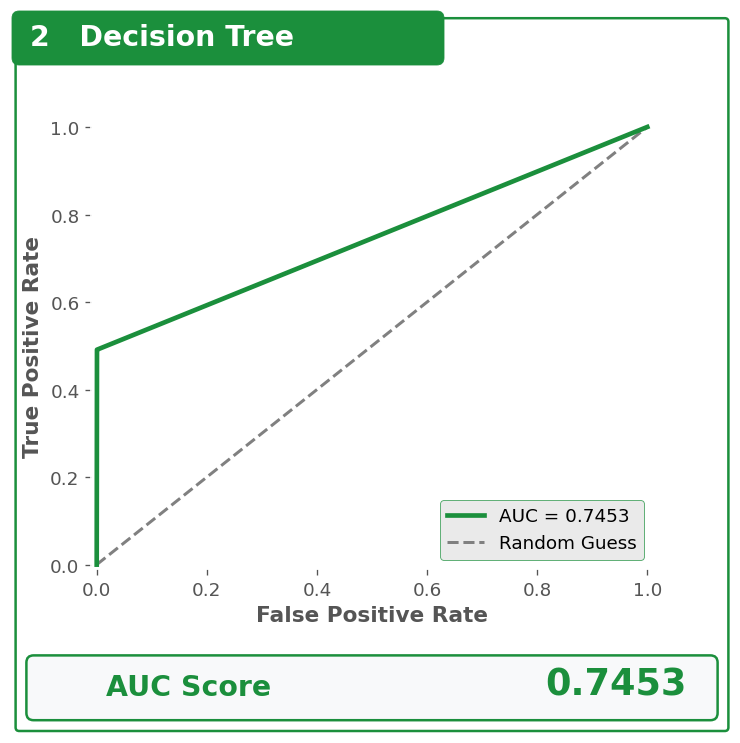

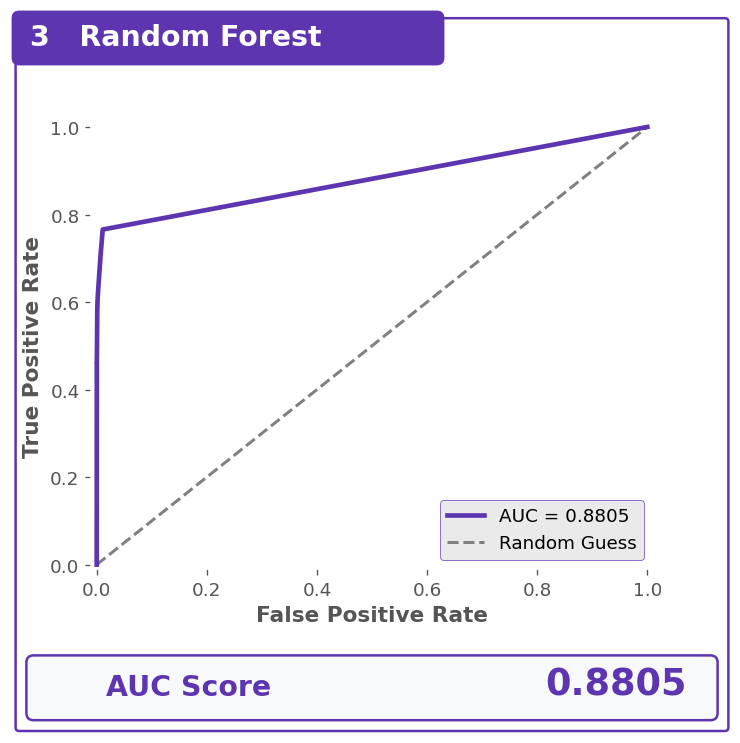

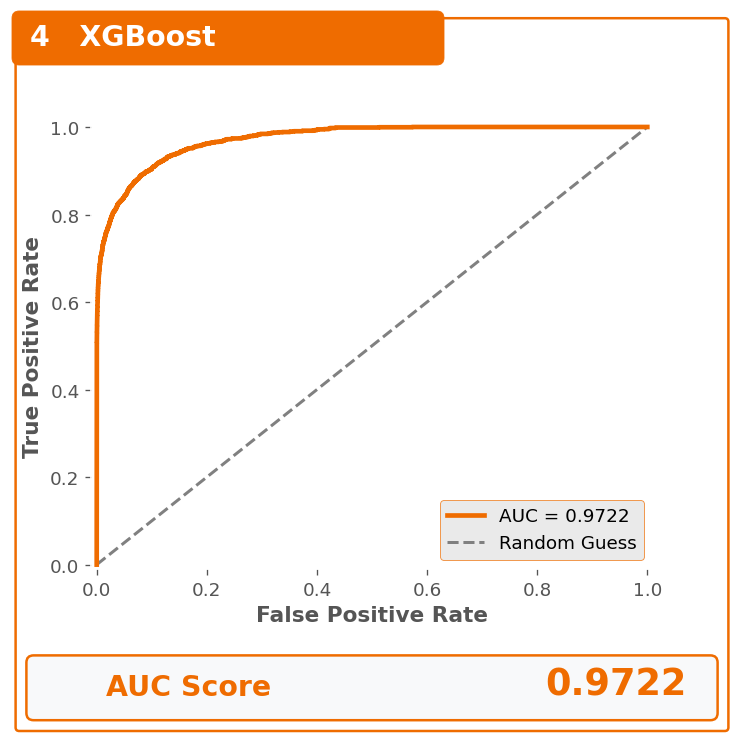

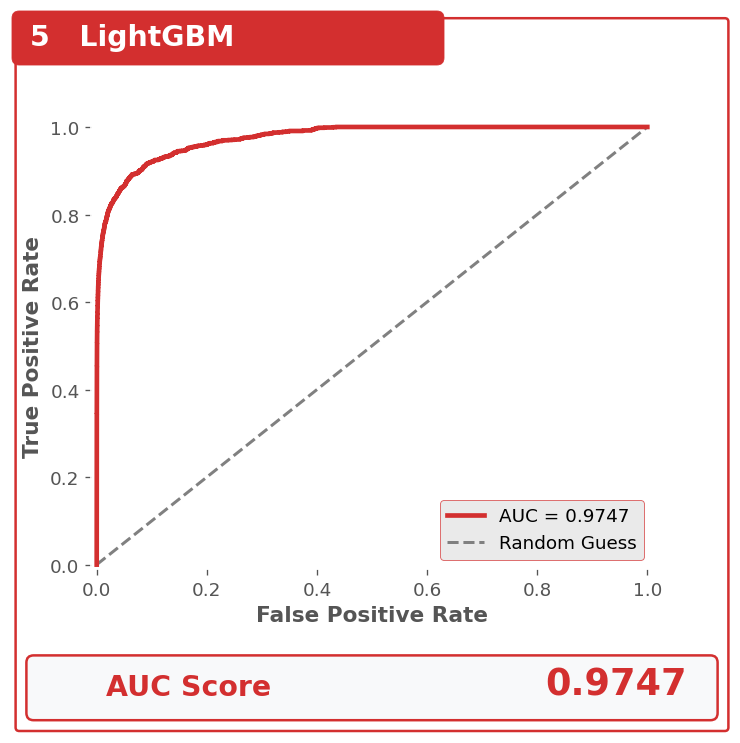

In [85]:
# ==========================================================
# ROC CURVE DASHBOARD (Professional Version)
# ==========================================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# สีของแต่ละโมเดล
model_colors = {
    "Logistic Regression": "#0D47A1",
    "Decision Tree": "#1B8F3C",
    "Random Forest": "#5E35B1",
    "XGBoost": "#EF6C00",
    "LightGBM": "#D32F2F"
}

for idx, (name, model) in enumerate(trained_models.items(), start=1):

    # Logistic Regression ใช้ข้อมูลที่ Scale
    if name == "Logistic Regression":
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        y_prob = model.predict_proba(X_test)[:,1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    # ==========================================================
    # Figure
    # ==========================================================

    fig = plt.figure(figsize=(6,6), dpi=120)
    fig.patch.set_facecolor("white")

    # ---------------- Border ----------------
    border = FancyBboxPatch(
        (0.01,0.01),
        0.98,
        0.98,
        transform=fig.transFigure,
        fill=False,
        edgecolor=model_colors[name],
        linewidth=1.5,
        boxstyle="round,pad=0.005"
    )

    fig.patches.append(border)

    # ---------------- Header ----------------

    header = FancyBboxPatch(
        (0.01,0.94),
        0.58,
        0.055,
        transform=fig.transFigure,
        facecolor=model_colors[name],
        edgecolor=model_colors[name],
        boxstyle="round,pad=0.01"
    )

    fig.patches.append(header)

    plt.figtext(
        0.025,
        0.958,
        f"{idx}   {name}",
        color="white",
        fontsize=17,
        fontweight="bold"
    )

    # ==========================================================
    # ROC Plot
    # ==========================================================

    ax = fig.add_axes([0.11,0.23,0.78,0.62])

    ax.set_facecolor("white")

    ax.plot(
        fpr,
        tpr,
        color=model_colors[name],
        linewidth=2.8,
        zorder=10,
        clip_on=False,
        label=f"AUC = {auc:.4f}"
    )

    ax.plot(
        [0,1],
        [0,1],
        "--",
        color="gray",
        linewidth=1.8,
        label="Random Guess"
    )

    # ป้องกันเส้นโดนตัด
    ax.set_xlim(-0.01,1.01)
    ax.set_ylim(-0.01,1.01)

    ax.set_xlabel(
        "False Positive Rate",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_ylabel(
        "True Positive Rate",
        fontsize=13,
        fontweight="bold"
    )

    ax.tick_params(labelsize=11)

    ax.grid(
        linestyle="--",
        alpha=0.25
    )

    # Legend
    legend = ax.legend(
        loc="lower right",
        fontsize=11,
        frameon=True
    )

    legend.get_frame().set_edgecolor(model_colors[name])

    # ==========================================================
    # Bottom Score Box
    # ==========================================================

    score_box = FancyBboxPatch(
        (0.03,0.03),
        0.94,
        0.07,
        transform=fig.transFigure,
        facecolor="#F8F9FA",
        edgecolor=model_colors[name],
        linewidth=1.5,
        boxstyle="round,pad=0.01"
    )

    fig.patches.append(score_box)

    plt.figtext(
        0.13,
        0.055,
        "AUC Score",
        fontsize=17,
        fontweight="bold",
        color=model_colors[name]
    )

    plt.figtext(
        0.74,
        0.055,
        f"{auc:.4f}",
        fontsize=22,
        fontweight="bold",
        color=model_colors[name]
    )

    # ==========================================================
    # Save รูป
    # ==========================================================

    plt.savefig(
        f"ROC_{name.replace(' ','_')}.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()
    plt.close()

    print("="*90)

## Precision-Recall Curve

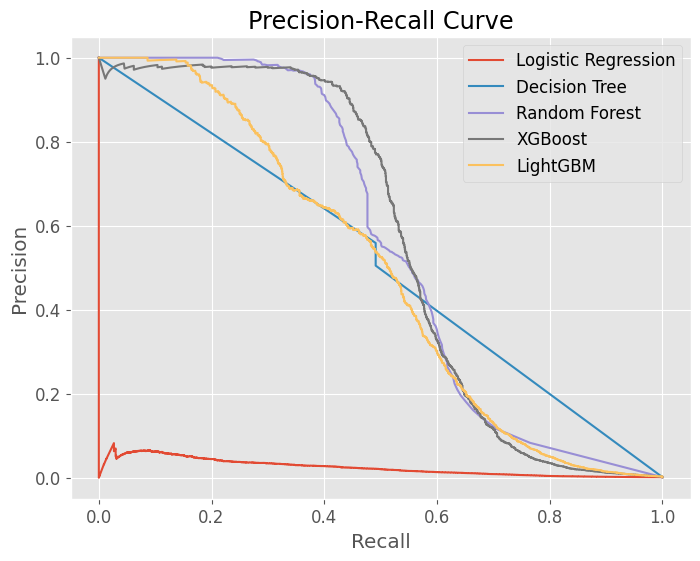

In [86]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

for name, model in trained_models.items():

    if name == "Logistic Regression":

        prob = model.predict_proba(X_test_scaled)[:,1]

    else:

        prob = model.predict_proba(X_test)[:,1]

    precision, recall, _ = precision_recall_curve(

        y_test,

        prob

    )

    plt.plot(

        recall,

        precision,

        label=name

    )

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.grid(True)

plt.show()

## Model Ranking

In [87]:
result_df = result_df.sort_values(

    by=["F1-Score","ROC-AUC"],

    ascending=False

)

display(result_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s)
3,XGBoost,0.999219,0.925295,0.429702,0.586866,0.972191,96.34
2,Random Forest,0.999117,0.769470,0.451004,0.568688,0.880497,2667.92
1,Decision Tree,0.998721,0.505006,0.491175,0.497994,0.745306,91.72
4,LightGBM,0.938534,0.018318,0.886184,0.035893,0.974690,108.74
0,Logistic Regression,0.874446,0.007469,0.729763,0.014787,0.854281,10.92


## Best Model

In [88]:
best_model = result_df.iloc[0]

print(best_model)

Model                 XGBoost
Accuracy             0.999219
Precision            0.925295
Recall               0.429702
F1-Score             0.586866
ROC-AUC              0.972191
Training Time (s)       96.34
Name: 3, dtype: object


## Bar Chart Comparison

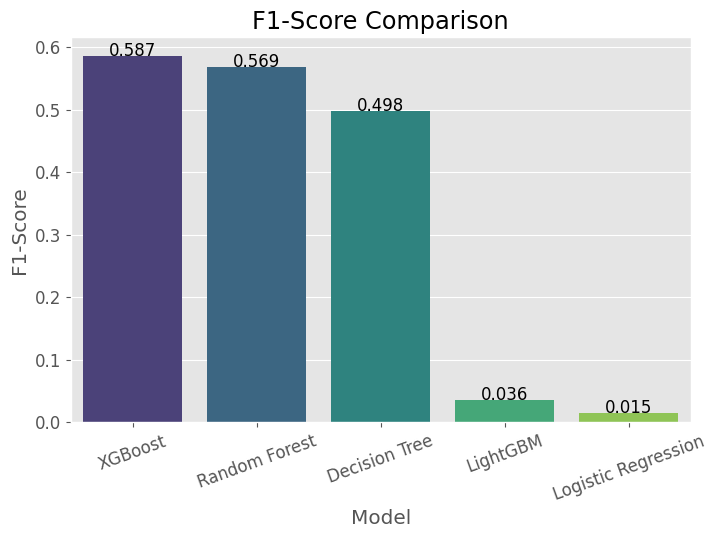

In [89]:
plt.figure(figsize=(8,5))

ax = sns.barplot(

    data=result_df,

    x="Model",

    y="F1-Score",

    palette="viridis"

)

plt.title("F1-Score Comparison")

plt.xticks(rotation=20)

for p in ax.patches:

    ax.annotate(

        f"{p.get_height():.3f}",

        (p.get_x()+p.get_width()/2,

         p.get_height()),

        ha="center"

    )

plt.show()

## ROC-AUC Comparison

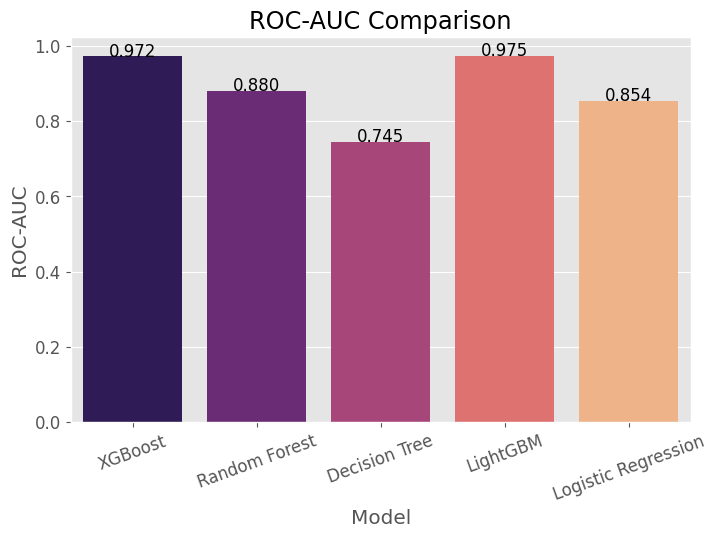

In [90]:
plt.figure(figsize=(8,5))

ax = sns.barplot(

    data=result_df,

    x="Model",

    y="ROC-AUC",

    palette="magma"

)

plt.title("ROC-AUC Comparison")

plt.xticks(rotation=20)

for p in ax.patches:

    ax.annotate(

        f"{p.get_height():.3f}",

        (p.get_x()+p.get_width()/2,

         p.get_height()),

        ha="center"

    )

plt.show()

# Feature Importance & Model Interpretation

## Random Forest Feature Importance

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rf_model = trained_models["Random Forest"]

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance.head(15))

,Feature,Importance
1,amount,0.386530
0,type,0.245514
4,day,0.192729
3,hour,0.175107
2,isFlaggedFraud,0.000120


## Plot Feature Importance

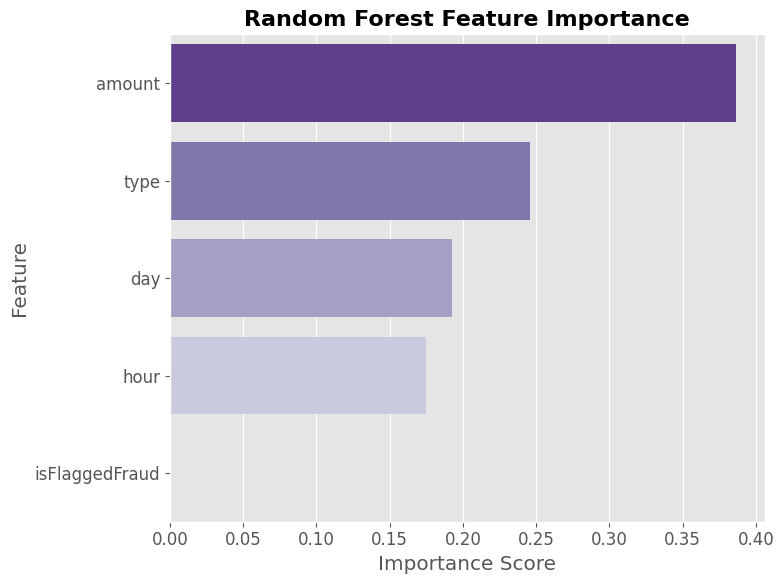

In [92]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature",
    palette="Purples_r"
)

plt.title(
    "Random Forest Feature Importance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## XGBoost Feature Importance

In [93]:
xgb_model = trained_models["XGBoost"]

importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": xgb_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

display(importance.head(15))

,Feature,Importance
0,type,0.662747
3,hour,0.145735
4,day,0.128202
1,amount,0.045879
2,isFlaggedFraud,0.017437


## Plot XGBoost

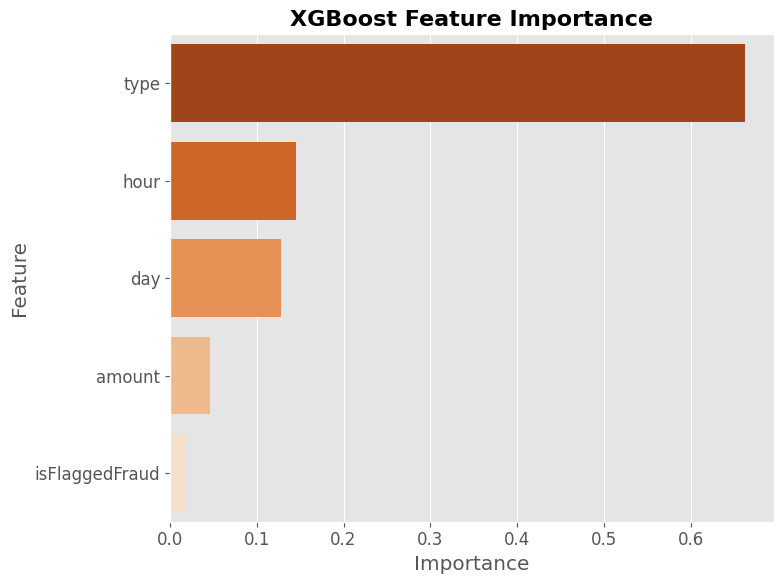

In [94]:
plt.figure(figsize=(8,6))

sns.barplot(

    data=importance.head(10),

    x="Importance",

    y="Feature",

    palette="Oranges_r"

)

plt.title(

    "XGBoost Feature Importance",

    fontsize=16,

    fontweight="bold"

)

plt.tight_layout()

plt.show()

## LightGBM Feature Importance

In [95]:
lgb_model = trained_models["LightGBM"]

importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": lgb_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

display(importance.head(15))

,Feature,Importance
1,amount,2265
4,day,1678
3,hour,1541
0,type,516
2,isFlaggedFraud,0


## Plot LightGBM

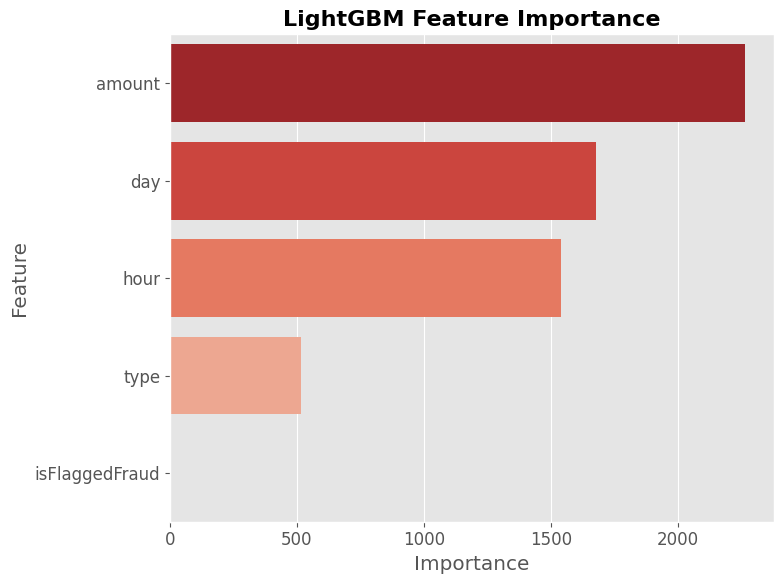

In [96]:
plt.figure(figsize=(8,6))

sns.barplot(

    data=importance.head(10),

    x="Importance",

    y="Feature",

    palette="Reds_r"

)

plt.title(

    "LightGBM Feature Importance",

    fontsize=16,

    fontweight="bold"

)

plt.tight_layout()

plt.show()

## เปรียบเทียบ Feature Importance

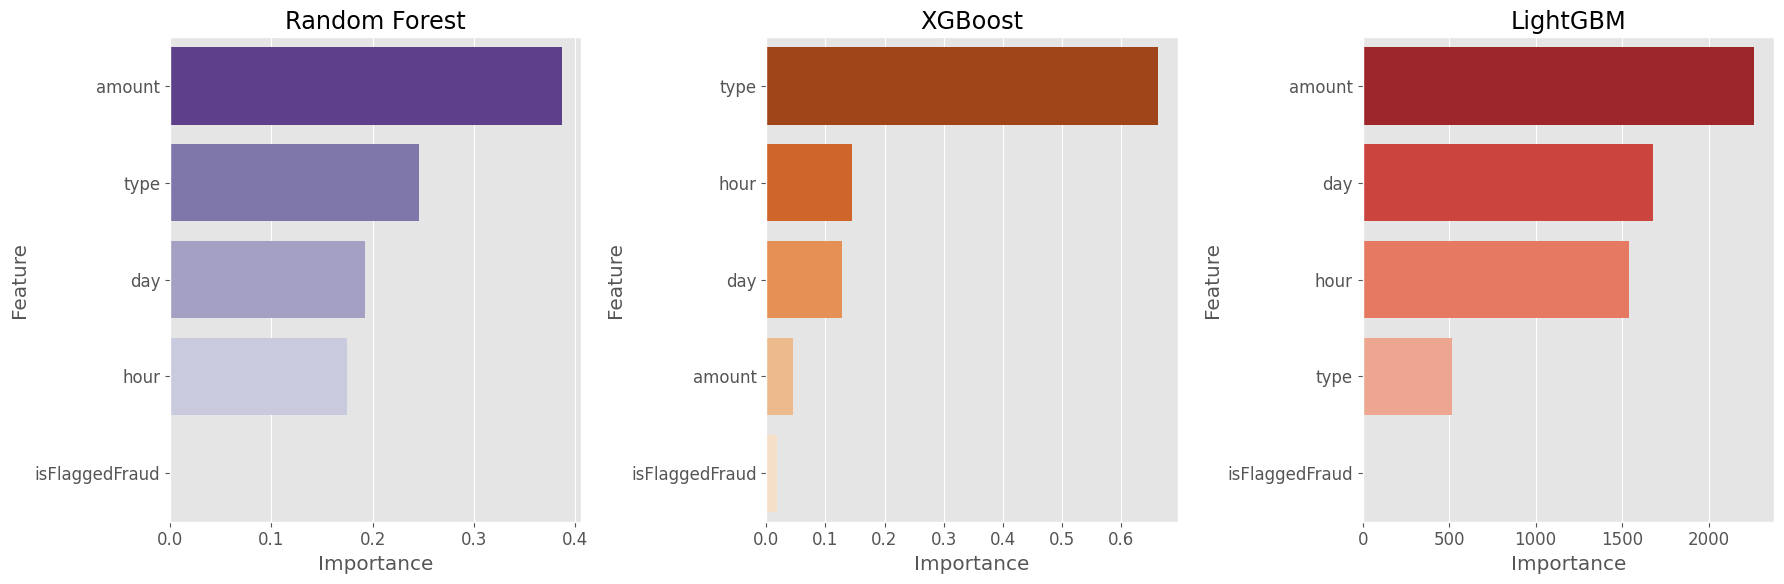

In [97]:
fig, axes = plt.subplots(1,3,figsize=(18,6))

models = {

    "Random Forest":
        ("Purples_r",
         trained_models["Random Forest"]),

    "XGBoost":
        ("Oranges_r",
         trained_models["XGBoost"]),

    "LightGBM":
        ("Reds_r",
         trained_models["LightGBM"])
}

for ax,(name,(palette,model)) in zip(axes,models.items()):

    imp = pd.DataFrame({

        "Feature":X_train.columns,

        "Importance":model.feature_importances_

    })

    imp = imp.sort_values(

        by="Importance",

        ascending=False

    ).head(10)

    sns.barplot(

        data=imp,

        x="Importance",

        y="Feature",

        palette=palette,

        ax=ax

    )

    ax.set_title(name)

plt.tight_layout()

plt.show()

# Model Comparison & Discussion

In [98]:
result_df = result_df.sort_values(
    by=["F1-Score","ROC-AUC"],
    ascending=False
)

result_df.style\
.background_gradient(
    cmap="YlGn",
    subset=["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]
)\
.format({
    "Accuracy":"{:.4f}",
    "Precision":"{:.4f}",
    "Recall":"{:.4f}",
    "F1-Score":"{:.4f}",
    "ROC-AUC":"{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s)
3,XGBoost,0.9992,0.9253,0.4297,0.5869,0.9722,96.340000
2,Random Forest,0.9991,0.7695,0.4510,0.5687,0.8805,2667.920000
1,Decision Tree,0.9987,0.5050,0.4912,0.4980,0.7453,91.720000
4,LightGBM,0.9385,0.0183,0.8862,0.0359,0.9747,108.740000
0,Logistic Regression,0.8744,0.0075,0.7298,0.0148,0.8543,10.920000


## Save Result

In [99]:
result_df.to_csv(
    "Model_Comparison.csv",
    index=False
)

print(result_df)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC  \
3              XGBoost  0.999219   0.925295  0.429702  0.586866  0.972191   
2        Random Forest  0.999117   0.769470  0.451004  0.568688  0.880497   
1        Decision Tree  0.998721   0.505006  0.491175  0.497994  0.745306   
4             LightGBM  0.938534   0.018318  0.886184  0.035893  0.974690   
0  Logistic Regression  0.874446   0.007469  0.729763  0.014787  0.854281   

   Training Time (s)  
3              96.34  
2            2667.92  
1              91.72  
4             108.74  
0              10.92  


## Radar Chart

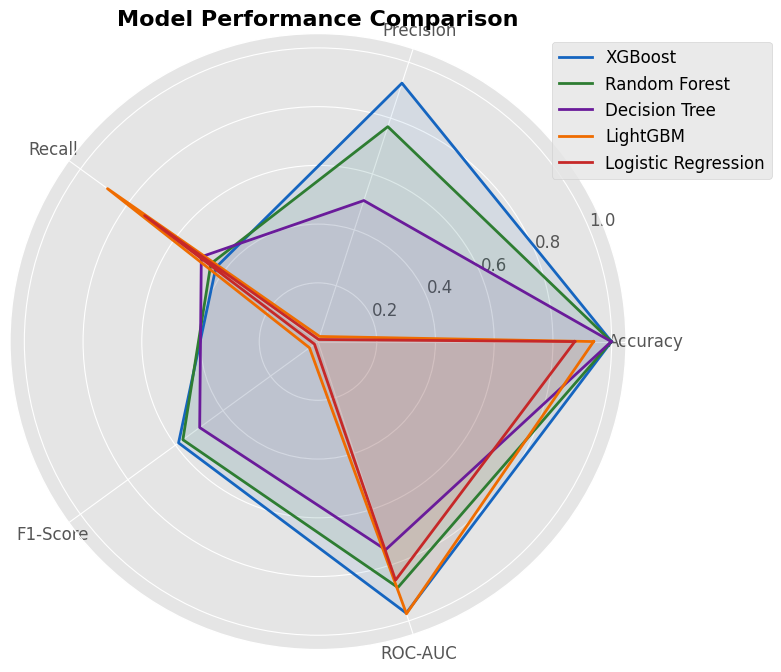

In [100]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]

labels = np.array(metrics)

angles = np.linspace(
    0,
    2*np.pi,
    len(labels),
    endpoint=False
)

angles = np.concatenate((angles,[angles[0]]))

plt.figure(figsize=(8,8))

ax = plt.subplot(111,polar=True)

colors = [
    "#1565C0",
    "#2E7D32",
    "#6A1B9A",
    "#EF6C00",
    "#C62828"
]

for color, (_, row) in zip(colors, result_df.iterrows()):

    values = row[metrics].tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row["Model"],
        color=color
    )

    ax.fill(
        angles,
        values,
        alpha=0.08,
        color=color
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title(
    "Model Performance Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.legend(
    bbox_to_anchor=(1.25,1)
)

plt.show()

## Ranking

In [101]:
ranking = result_df.copy()

ranking.insert(
    0,
    "Rank",
    range(1,len(ranking)+1)
)

display(ranking)

,Rank,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s)
3,1,XGBoost,0.999219,0.925295,0.429702,0.586866,0.972191,96.34
2,2,Random Forest,0.999117,0.769470,0.451004,0.568688,0.880497,2667.92
1,3,Decision Tree,0.998721,0.505006,0.491175,0.497994,0.745306,91.72
4,4,LightGBM,0.938534,0.018318,0.886184,0.035893,0.974690,108.74
0,5,Logistic Regression,0.874446,0.007469,0.729763,0.014787,0.854281,10.92


## Best Model

In [102]:
best = ranking.iloc[0]

print("="*60)

print("BEST MODEL")

print("="*60)

print(best)

BEST MODEL
Rank                        1
Model                 XGBoost
Accuracy             0.999219
Precision            0.925295
Recall               0.429702
F1-Score             0.586866
ROC-AUC              0.972191
Training Time (s)       96.34
Name: 3, dtype: object


In [103]:
best = result_df.iloc[0]

print(f"""
The experimental results indicate that
{best['Model']}
achieved the best overall performance.

Accuracy : {best['Accuracy']:.4f}

Precision : {best['Precision']:.4f}

Recall : {best['Recall']:.4f}

F1-score : {best['F1-Score']:.4f}

ROC-AUC : {best['ROC-AUC']:.4f}

Therefore, this model was selected as the final fraud detection model.
""")


The experimental results indicate that
XGBoost
achieved the best overall performance.

Accuracy : 0.9992

Precision : 0.9253

Recall : 0.4297

F1-score : 0.5869

ROC-AUC : 0.9722

Therefore, this model was selected as the final fraud detection model.

